In [1]:
import pandas_datareader as pdr
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sms
from datetime import datetime

In [2]:
df=pd.read_csv('TATAMOTORS.csv')

In [3]:
df.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-09-01,540.500000,546.650024,540.000000,543.650024,543.650024,7571854
1,2016-09-02,552.000000,555.900024,549.099976,549.849976,549.849976,10097146
2,2016-09-06,556.349976,593.299988,556.349976,588.700012,588.700012,15813178


In [4]:
df.tail(3)

,Date,Open,High,Low,Close,Adj Close,Volume
1229,2021-08-26,284.850006,287.350006,281.649994,284.299988,284.299988,17864053
1230,2021-08-27,282.899994,286.799988,281.700012,285.750000,285.750000,13477390
1231,2021-08-30,290.100006,293.500000,289.899994,291.950012,291.950012,17217097


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1232 non-null   object 
 1   Open       1232 non-null   float64
 2   High       1232 non-null   float64
 3   Low        1232 non-null   float64
 4   Close      1232 non-null   float64
 5   Adj Close  1232 non-null   float64
 6   Volume     1232 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 67.5+ KB


In [6]:
df.shape

(1232, 7)

<AxesSubplot:>

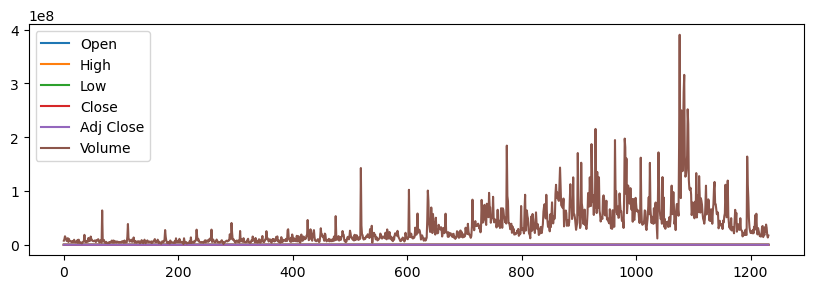

In [7]:
df.plot(figsize=(10,3))

<AxesSubplot:>

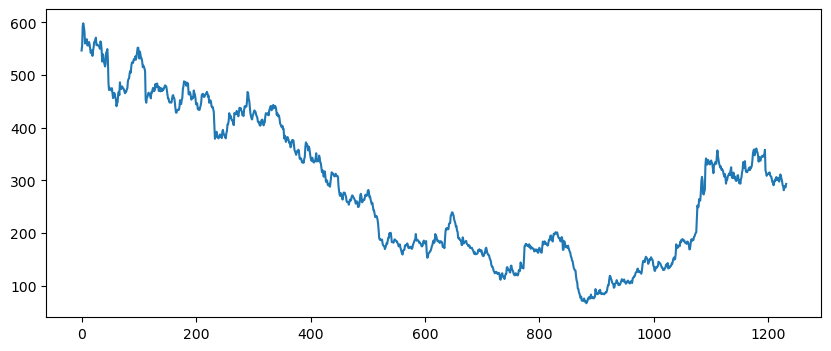

In [8]:
df['High'].plot(figsize=(10,4))

<AxesSubplot:>

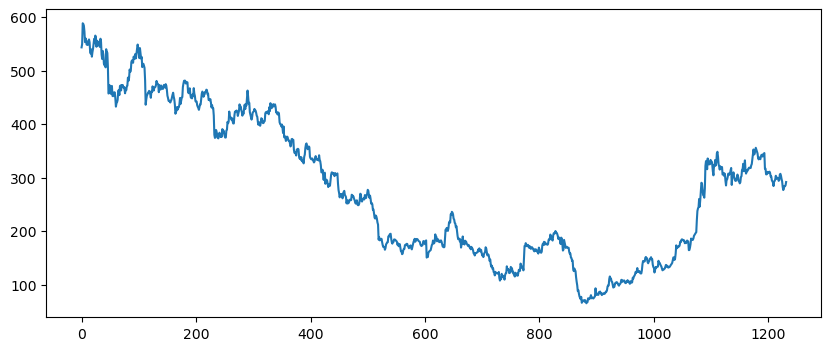

In [9]:
df['Close'].plot(figsize=(10,4))

<AxesSubplot:>

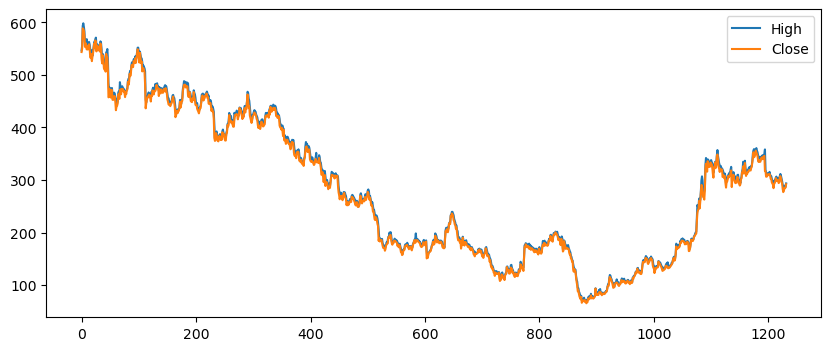

In [10]:
df[['High','Close']].plot(figsize=(10,4))

<AxesSubplot:>

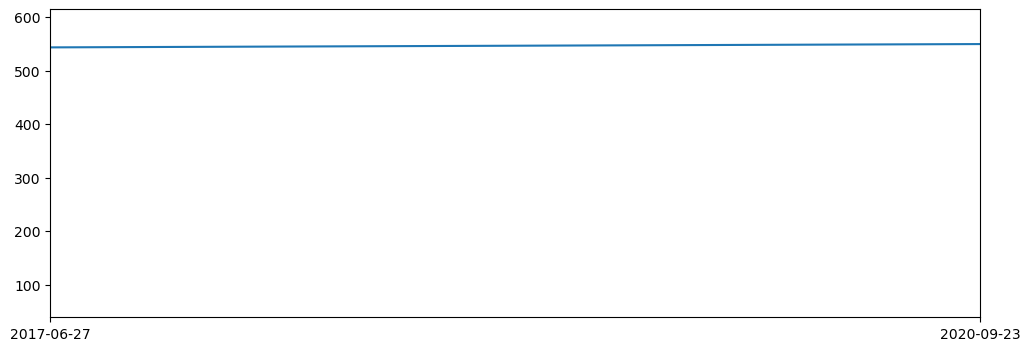

In [12]:
## xlimit and y limit
df['Close'].plot(xlim=['2017-06-27','2020-09-23'],figsize=(12,4))
# df['High'].plot(xlim=['2017-06-27','2020-09-23'])

In [ ]:
df['Close'].plot(xlim=['2020-01-01','2022-09-01'],ylim=[0,1000],figsize=(12,4))

In [13]:
df.index

RangeIndex(start=0, stop=1232, step=1)

# Time Resampling

In [14]:
df.resample(rule='A').min() 
#It gives us MIN values of all parameters in each year.

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [15]:
df.resample(rule='A').max()  
#It gives us MAX values of all parameters in each year.

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [ ]:
##rule = A : year end frequency
df.resample(rule='A').max()[['Open','Close']].plot(figsize=(15,8))
# PLOT open max price over the year

In [ ]:
df.resample(rule='QS').max()
##RULE QS : quaterly start frequency--> after three months

In [ ]:
##RULE QS : quaterly start frequency--> after three months 
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='QS').max()[['High','Close']].plot()

In [ ]:
##RULE BA : Business End Frequency
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='BA').max()

In [ ]:
df.resample(rule='BQS').max()

In [ ]:
##plotting
df['Close'].resample(rule='A').mean().plot(kind='bar')

In [ ]:
# RULE M : monthly data
df['Open'].resample(rule='M').max().plot(kind='bar',figsize=(15,6))

In [ ]:
df['High'].rolling(11).mean().head(20)

In [ ]:
df['High'].rolling(11).max().head(20)

In [ ]:
df.head()

In [ ]:
# simple moving average
df['Open:30 days rolling']=df['Open'].rolling(30).mean()

In [ ]:
df.head(31)

In [ ]:
df[['Open','Open:30 days rolling']].plot(figsize=(12,5))

In [ ]:
# here we specify xlim 
df[['Open','Open:30 days rolling']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [ ]:
df['Open:10 days rolling']=df['Open'].rolling(10).mean()
df['Open:30 days rolling']=df['Open'].rolling(30).mean()
df['Open:50 days rolling']=df['Open'].rolling(50).mean()

In [ ]:
df[['Open','Open:10 days rolling','Open:30 days rolling','Open:50 days rolling']].plot(figsize=(12,5))

In [ ]:
# cumulative moving average(here I use for only open stock)
# use expanding
df['Open'].expanding().mean().plot(figsize=(10,5))

In [ ]:
#  exponential moving average
df['EMA_0.1'] = df['Open'].ewm(alpha=0.1, adjust=False).mean()

In [ ]:
df[['Open','EMA_0.1']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [ ]:
df['EMA_0.3'] = df['Open'].ewm(alpha=0.3, adjust=False).mean()

In [ ]:
df[['Open','EMA_0.1','EMA_0.3']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [ ]:
# exponential weightage moving average -- more smoothen curve
df['EWMA_5days'] = df['Open'].ewm(span=5).mean()

In [ ]:
df[['Open','EMA_0.1','EWMA_5days']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [ ]:
df['EMA_0.33333'] = df['Open'].ewm(alpha=0.33333, adjust=False).mean()

In [ ]:
df[['Open','EMA_0.33333','EWMA_5days']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))
# both alpha =0.3 and span =5 is same almost 

In [ ]:
df

# STAT MODEL WITH ARIMA

In [11]:
# since it is seasonal data we are going to use dickey fuller test
from statsmodels.tsa.stattools import adfuller

In [12]:
# H0 : It is not stationary
# H1 : It is stationary

In [13]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

#strong evidence against the null hypothesis, reject the null hypothesis. 
#Data has no unit root and is stationary

#weak evidence against null hypothesis, time series has a unit root, 
#indicating it is non-stationary 

In [15]:
df1=pd.read_csv('TATAMOTORS.csv')
df1.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-09-01,540.500000,546.650024,540.000000,543.650024,543.650024,7571854
1,2016-09-02,552.000000,555.900024,549.099976,549.849976,549.849976,10097146
2,2016-09-06,556.349976,593.299988,556.349976,588.700012,588.700012,15813178


In [16]:
adf_test(df1['Close'])

ADF Statistics: -1.9956242496580394
p- value: 0.28849500297868563
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [17]:
## Use Techniques Differencing --> 
# one dayy differencing to convery into stationary data
# we can;t work with seasonal data
df1['first_diff_Close']=df1['Close']-df1['Close'].shift(1)

In [18]:
df1.head()

,Date,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
0,2016-09-01,540.500000,546.650024,540.000000,543.650024,543.650024,7571854,NaN
1,2016-09-02,552.000000,555.900024,549.099976,549.849976,549.849976,10097146,6.199952
2,2016-09-06,556.349976,593.299988,556.349976,588.700012,588.700012,15813178,38.850036
3,2016-09-07,590.000000,598.400024,584.000000,587.400024,587.400024,13408927,-1.299988
4,2016-09-08,590.750000,591.700012,577.750000,584.200012,584.200012,10456258,-3.200012


In [19]:
adf_test(df1['first_diff_Close'].dropna())

ADF Statistics: -33.44720329273105
p- value: 0.0
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [20]:
# now time to determine p(pacf) and q(acf) value
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

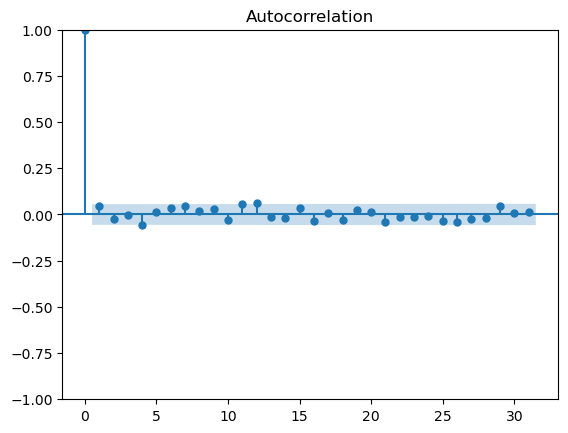

In [21]:
acf = plot_acf(df1["first_diff_Close"].dropna())
# q = 1 ---> assume by lookig at picture

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


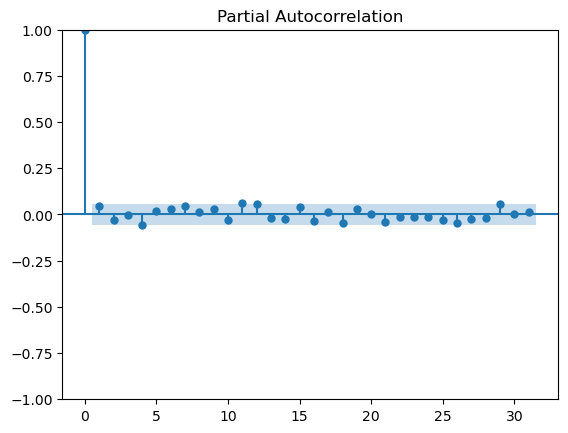

In [22]:
acf12 = plot_pacf(df1["first_diff_Close"].dropna())
# p = 1
# d = seasonal different , here d =1

In [23]:
df1.shape

(1232, 8)

In [24]:
### split train and test data
df1.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
0,2016-09-01,540.500000,546.650024,540.000000,543.650024,543.650024,7571854,NaN
1,2016-09-02,552.000000,555.900024,549.099976,549.849976,549.849976,10097146,6.199952
2,2016-09-06,556.349976,593.299988,556.349976,588.700012,588.700012,15813178,38.850036


In [25]:
df1.tail(3)

,Date,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
1229,2021-08-26,284.850006,287.350006,281.649994,284.299988,284.299988,17864053,-0.100006
1230,2021-08-27,282.899994,286.799988,281.700012,285.750000,285.750000,13477390,1.450012
1231,2021-08-30,290.100006,293.500000,289.899994,291.950012,291.950012,17217097,6.200012


<AxesSubplot:>

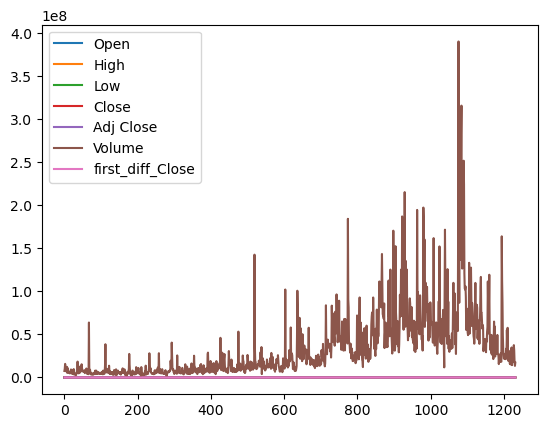

In [26]:
df1.plot()

In [27]:
from datetime import datetime,timedelta
train_dataset_end=datetime(2021,12,1)
test_dataset_end=datetime(2022,12,14)


In [28]:
train_data=df1[:train_dataset_end]
test_data=df1[train_dataset_end+timedelta(days=1):test_dataset_end]

TypeError: cannot do slice indexing on RangeIndex with these indexers [2021-12-01 00:00:00] of type datetime

In [ ]:
train_data

In [ ]:
train_data['Close'].plot()

In [ ]:
test_data

In [ ]:
## create a ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
model_ARIMA=ARIMA(df1['Close'],order=(1,1,1))

In [ ]:
model_Arima_fit=model_ARIMA.fit()

In [ ]:
model_Arima_fit.summary()

In [ ]:
test_data

In [ ]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

In [ ]:
pred=model_Arima_fit.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data['Close']-pred

In [ ]:
pred

In [ ]:
residuals

In [ ]:
model_Arima_fit.resid.plot(kind='kde')

In [ ]:
test_data['Predicted_ARIMA']=pred

In [ ]:
test_data[['Close','Predicted_ARIMA']].plot(figsize=(15,10))

In [ ]:
pred

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [ ]:
rmse= sqrt(mean_squared_error(pred,test_data['Close']))
rmse

In [ ]:
test_data['Close'].mean()
# as rmse is very lesser than mean then our model is a good model

In [ ]:
##prediction
pred_start_date=test_data.index[-1]
pred_end_date='2023-02-20 00:00:00'
print(pred_start_date)
print(pred_end_date)

In [ ]:
index_future_dates = pd.date_range(start='2022-12-14',end='2023-02-20')
pred1=model_Arima_fit.predict(start=len(df1),end=len(df1)+68)
pred1.index=index_future_dates
# residuals1=test_data['Close']-pred1

In [ ]:
pred1

In [ ]:
pred1.plot()

In [ ]:
model2=ARIMA(df1['Close'],order=(1,1,1))
model2=model2.fit()
df1.tail()

In [ ]:
index_future_dates=pd.date_range(start='2022-12-14',end='2023-01-31')
pred2=model2.predict(start=len(df1),end=len(df1)+48,typ='levels').rename('ARIMA Predictions')
pred2.index=index_future_dates

In [ ]:
pred2.plot()

In [ ]:
zsfczv

# automate the process

In [ ]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

In [ ]:
stepwise_fit=auto_arima(df1['Close'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

In [ ]:
#best value od p,d,q --> (1,1,2)

In [ ]:
model_ARIMA_best=ARIMA(df1['Close'],order=(1,1,2))

In [ ]:
model_Arima_fit_best=model_ARIMA_best.fit()

In [ ]:
model_Arima_fit_best.summary()

In [ ]:
test_data

In [ ]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

In [ ]:
pred_best=model_Arima_fit_best.predict(start=pred_start_date,end=pred_end_date)
residuals_best=test_data['Close']-pred_best

In [ ]:
pred_best

In [ ]:
residuals_best

In [ ]:
model_Arima_fit_best.resid.plot(kind='kde')

In [ ]:
test_data['Predicted_ARIMA']=pred_best

In [ ]:
test_data[['Close','Predicted_ARIMA']].plot(figsize=(15,10))

In [ ]:
pred_best

In [ ]:
rmse_best= sqrt(mean_squared_error(pred_best,test_data['Close']))
rmse_best

In [ ]:
test_data['Close'].mean()

In [ ]:
##prediction
pred_start_date=test_data.index[-1]
pred_end_date='2022-12-31 00:00:00'
print(pred_start_date)
print(pred_end_date)

In [ ]:
index_future_dates = pd.date_range(start='2022-11-11',end='2022-11-21')
pred1_best=model_Arima_fit_best.predict(start=len(df1),end=len(df1)+10)
pred1_best.index=index_future_dates
# residuals1=test_data['Close']-pred1

In [ ]:
pred1_best

In [ ]:
pred1_best.plot()

# USING MACHINE LEARNING

In [ ]:
X = df1[["Open", "High", "Low", "Adj Close"]]
Y = df1["Close"]
X = X.to_numpy()
Y = Y.to_numpy()
Y = Y.reshape(-1, 1)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [ ]:
def create_model(model):
    model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
#find the mean squared error
    print("Root Mean Squared error : ",sqrt(mean_squared_error(Y_test,Y_pred)))
#find the r2_score
    print("R2 Score : ",r2_score(Y_test,Y_pred))
    print("Training score : ",model.score(X_train,Y_train))
    print("Testing score : ",model.score(X_test,Y_test))
    return model,Y_pred

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
#create object of LinearRegression class
lr=LinearRegression()

In [ ]:
lr,Y_pred=create_model(lr)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt,Y_pred=create_model(dt)

In [ ]:
from sklearn.svm import SVR
svr = SVR()
svr,Y_pred=create_model(svr)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth=3)
rfr,Y_pred=create_model(rfr)

In [ ]:
a=pd.DataFrame(Y_pred)
a

In [ ]:
a.plot(figsize=(10,5))

In [ ]:
df2 = df1["Close"]
len(df2)

In [ ]:
train=df2.iloc[:1000]
test=df2.iloc[1000:]

In [ ]:
test

In [ ]:
df1=df1.iloc[1:]

In [ ]:
X = df1.drop(['Close'], axis=1)
y = df1['Close']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X.head()

In [ ]:
#now lets split data in test train pairs

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=False)

Acc = []

In [ ]:
from sklearn.linear_model import LinearRegression

# model training

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

In [ ]:
# prediction
y_pred_1 = model_1.predict(X_test)
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_1})
pred_df.head()

In [ ]:
# Measure the Accuracy Score

from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_1)))
Acc.append(r2_score(y_test, y_pred_1))
#Accuracy score of the predictions: 0.9931342019332019

In [ ]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model_2 = DecisionTreeRegressor()
model_2.fit(X_train, y_train)

# prediction
y_pred_2 = model_2.predict(X_test)
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_2})
pred_df.head()

# Measure the Accuracy Score
from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_2)))
Acc.append(r2_score(y_test, y_pred_2))

In [ ]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

In [ ]:
df1

In [ ]:
df1=df1.reset_index('Date')

In [ ]:
# Select only the important features i.e. the date and price
df1 = df1[["Date","Close"]] # select Date and Price
# Rename the features: These names are NEEDED for the model fitting
df1 = df1.rename(columns = {"Date":"ds","Close":"y"}) #renaming the columns of the dataset
df1.head()

In [ ]:
!pip install fbprophet

In [ ]:
from fbprophet import Prophet
m = Prophet(daily_seasonality = True) # the Prophet class (model)
m.fit(df1) # fit the model using all data

In [ ]:
future = m.make_future_dataframe(periods=365) #we need to specify the number of days in future
prediction = m.predict(future)
m.plot(prediction)
plt.title("Prediction of the Tesla Stock Price using the Prophet")
plt.xlabel("Date")
plt.ylabel("Close Stock Price")
plt.show()